# Sopa Workflow to analyze visium HD samples

Activate sopa_env_kernel

https://gustaveroussy.github.io/sopa/tutorials/visium_hd/ 

In [62]:
import spatialdata
import sopa

import spatialdata_plot

import scanpy as sc

from __future__ import annotations

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [63]:
# Naomie Colormaps
from matplotlib.colors import LinearSegmentedColormap
violet_colors = ["#f3e5f5", "#ce93d8", "#ab47bc", "#6a1b9a", "#4a148c"]
violet_cmap = LinearSegmentedColormap.from_list("violet_gradient", violet_colors)
# Slightly darker to better appreciate the tissue 
violet_colors_2 = ["#e1c9e4", "#ce93d8", "#ab47bc", "#6a1b9a", "#4a148c"]
violet_cmap_2 = LinearSegmentedColormap.from_list("violet_gradient", violet_colors_2)
# orange _ red map
orange_red_palette = ["#e5e7e9", "#f6ddcc", "#f0b27a", "#ca6f1e", "#c0392b", "#922b21"]
orange_red_cmap = LinearSegmentedColormap.from_list("range_gradient", orange_red_palette)


## If segmentation has not been done already (otherwise, re-start below already)

### Load data

In [64]:
# Image(s) #

## EOM
#dir_base_image = '/pasteur/helix/projects/CSD_hpc/data/lab/spatial/EOM_VisiumHD/scan_he/tiff_converted/'
#filename_image = 'sample_D1_highres_rgb.tif'

## Embryo head
dir_base_image = '/pasteur/helix/projects/CSD_hpc/data/lab/spatial/embryo_head_VisiumHD/images/'
# A1
filename_image = 'A1_highres_RGB.tif'
# D1
#filename_image = 'D1_highres_RGB.tif'



# Space Ranger output #

## EOM
# A1
#dir_base_gex ="/pasteur/helix/projects/CSD_hpc/data/lab/spatial/EOM_VisiumHD/counts/Sample_A1/outs/"
#filename_gex = ""
# D1
#dir_base_gex ="/pasteur/helix/projects/CSD_hpc/data/lab/spatial/EOM_VisiumHD/counts/Sample_D1/outs/"
#filename_gex = ""

## Embryo head
# A1
dir_base_gex = "/pasteur/helix/projects/CSD_hpc/Naomie/visiumHD/visiumHD_outputs/embryo_head/counts/Sample_A1/outs/"
filename_gex = ""
# D1
#dir_base_gex = "/pasteur/helix/projects/CSD_hpc/Naomie/visiumHD/visiumHD_outputs/embryo_head/counts/Sample_D1/outs/"
#filename_gex = ""

In [33]:
sdata = sopa.io.visium_hd(
    dir_base_gex,  # Space Ranger output directory containing the feature_slice.h5 file
    fullres_image_file=dir_base_image + filename_image,  # not needed for this tuto
    dataset_id=filename_gex,  # if Space Ranger produced files with no prefix, just put ""
)

# Save image
#sdata.write("data/embryo_head_A1.zarr", overwrite=True) 
sdata.write("data/embryo_head_D1.zarr", overwrite=True) 
#sdata.write("data/EOM_D1.zarr", overwrite=True) 

anndata.py (1794): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1794): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1794): Variable names are not unique. To make them unique, call `.var_names_make_unique`.
anndata.py (1794): Variable names are not unique. To make them unique, call `.var_names_make_unique`.


INFO     The Zarr backing store has been changed from None the new file path: data/embryo_head_D1.zarr             


Load image (don't run what's previously then):

In [65]:
sdata = spatialdata.read_zarr("data/embryo_head_A1.zarr")
#sdata = spatialdata.read_zarr("data/embryo_head_D1.zarr")  
#sdata = spatialdata.read_zarr("data/EOM_D1.zarr")  
sdata

version mismatch: detected: RasterFormatV02, requested: FormatV04
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/

SpatialData object, with associated Zarr store: /pasteur/helix/projects/fast_npz/Naomie/Shahragim_Project/visium_HD/spatial_EOM/sopa/data/embryo_head_A1.zarr
├── Images
│     ├── '_full_image': DataTree[cyx] (3, 38938, 26937), (3, 19469, 13468), (3, 9734, 6734), (3, 4867, 3367), (3, 2433, 1683)
│     ├── '_hires_image': DataArray[cyx] (3, 6000, 4151)
│     └── '_lowres_image': DataArray[cyx] (3, 600, 415)
├── Shapes
│     ├── '_square_002um': GeoDataFrame shape: (3907539, 1) (2D shapes)
│     ├── '_square_008um': GeoDataFrame shape: (246638, 1) (2D shapes)
│     ├── '_square_010um': GeoDataFrame shape: (158381, 1) (2D shapes)
│     ├── '_square_016um': GeoDataFrame shape: (62498, 1) (2D shapes)
│     ├── 'image_patches': GeoDataFrame shape: (191, 3) (2D shapes)
│     ├── 'region_of_interest': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'stardist_boundaries': GeoDataFrame shape: (166530, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (3907539, 18085)
      ├── 'square_

In [66]:
# let's make the var names unique; this improves performance in accessing the tabular data and is necessary to be able to plot the data
for table in sdata.tables.values():
    table.var_names_make_unique()

INFO     Rasterizing image for faster rendering.                                                                   


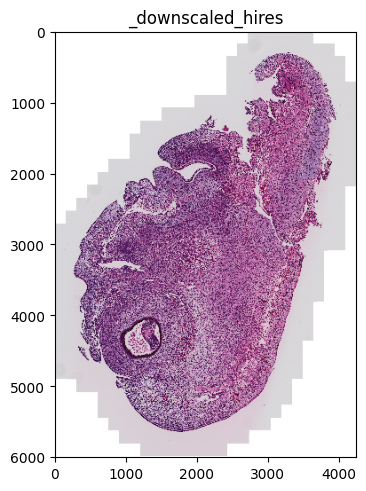

In [9]:
sdata.pl.render_images("_hires_image").pl.show('_downscaled_hires')

### Pipeline

**CAN ADD A TISSUE SEGMENTATION STEP HERE, IF DESIRED, ESPECIALLY IF TISSUE IS SPARSE as we will not run segmentation on patches that are outside of the tissue.**

In [67]:
sopa.segmentation.tissue(sdata)

[INFO] (sopa.segmentation._tissue) Using image_key='_hires_image' and mode='saturation' as default
[WARNING] (sopa.segmentation._tissue) sdata['region_of_interest'] was already existing, but tissue segmentation is run on top


INFO     Dropping coordinate system '_downscaled_lowres' since it doesn't have relevant elements.                  


/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/spatialdata/_core/spatialdata.py:184: UserWarning: The table is annotating 'stardist_boundaries', which is not present in the SpatialData object.
  self.validate_table_in_spatialdata(v)


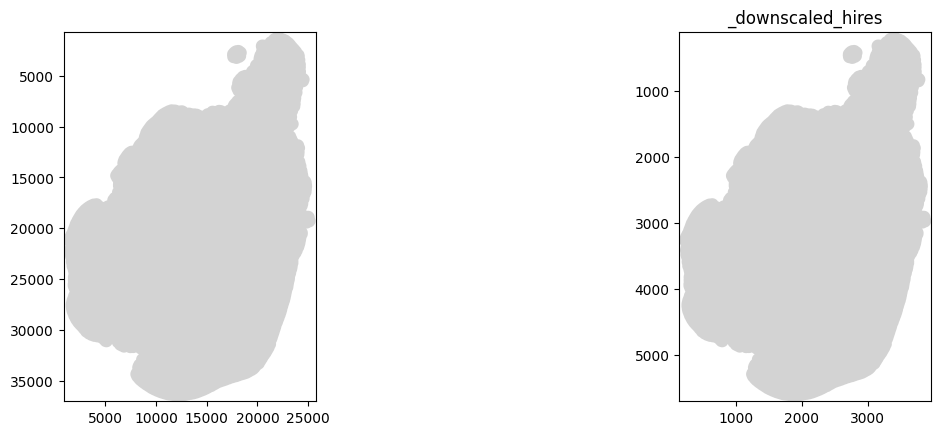

In [68]:
sdata.pl.render_shapes('region_of_interest').pl.show()

#### **Segmentation**

In [18]:
# Parallelize
### sopa.settings.parallelization_backend = "dask" #THIS WAS GENERATING TIMEOUT ERROR, it was used to speed up but it works better without (at lest for embryo head D1)

In [69]:
# Create the patches for cell segmentation
sopa.make_image_patches(sdata)

[INFO] (sopa.patches._patches) Added 191 patch(es) to sdata['image_patches']


INFO     Dropping coordinate system '_downscaled_lowres' since it doesn't have relevant elements.                  
INFO     Dropping coordinate system '_downscaled_hires' since it doesn't have relevant elements.                   


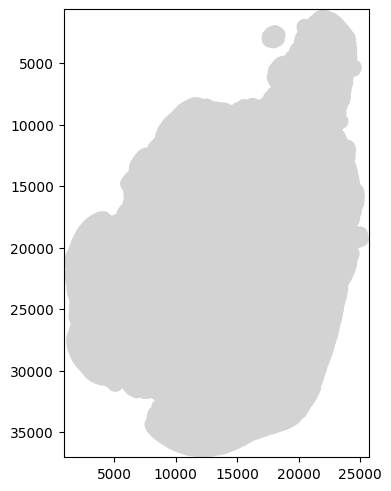

In [70]:
sdata.pl.render_shapes("image_patches").pl.show()

In [71]:
# Run Stardist segmentation on SpatialData object, 
# and add a GeoDataFrame containing the cell boundaries.


## Parameters of the StarDist model ##
# Larger prob_thresh value will result in fewer segmented objects
# Smaller nms_thresh will reduce the probability of nuclei overlap
#prob_thresh = 0.2 #Default value: 0.2
#nms_thresh = 0.6 #Default value

# Test: use same params as in nuclei_segmentation.ipynb
prob_thresh = 0.3
nms_thresh = 0.0001

sopa.segmentation.stardist(sdata, min_area=10) #I decrease it cause it does not find segmented cells for embryo head samples
sdata

[WARNING] (sopa._settings) Running without parallelization backend can be slow. Consider using a backend, e.g. via `sopa.settings.parallelization_backend = 'dask'`, or `export SOPA_PARALLELIZATION_BACKEND=dask`.
  2%|▏         | 4/191 [00:31<22:50,  7.33s/it]

  3%|▎         | 5/191 [00:37<21:33,  6.96s/it]

100%|██████████| 191/191 [56:11<00:00, 17.65s/it]
[INFO] (sopa.segmentation._stainings) Found 175836 total cells
Resolving conflicts: 100%|██████████| 80400/80400 [00:23<00:00, 3491.32it/s]
[INFO] (sopa.segmentation._stainings) Added 165203 cell boundaries in sdata['stardist_boundaries']


SpatialData object, with associated Zarr store: /pasteur/helix/projects/fast_npz/Naomie/Shahragim_Project/visium_HD/spatial_EOM/sopa/data/embryo_head_A1.zarr
├── Images
│     ├── '_full_image': DataTree[cyx] (3, 38938, 26937), (3, 19469, 13468), (3, 9734, 6734), (3, 4867, 3367), (3, 2433, 1683)
│     ├── '_hires_image': DataArray[cyx] (3, 6000, 4151)
│     └── '_lowres_image': DataArray[cyx] (3, 600, 415)
├── Shapes
│     ├── '_square_002um': GeoDataFrame shape: (3907539, 1) (2D shapes)
│     ├── '_square_008um': GeoDataFrame shape: (246638, 1) (2D shapes)
│     ├── '_square_010um': GeoDataFrame shape: (158381, 1) (2D shapes)
│     ├── '_square_016um': GeoDataFrame shape: (62498, 1) (2D shapes)
│     ├── 'image_patches': GeoDataFrame shape: (191, 3) (2D shapes)
│     ├── 'region_of_interest': GeoDataFrame shape: (2, 1) (2D shapes)
│     └── 'stardist_boundaries': GeoDataFrame shape: (165203, 1) (2D shapes)
└── Tables
      ├── 'square_002um': AnnData (3907539, 18085)
      ├── 'square_

In [21]:
#sdata.pl.render_shapes("stardist_boundaries").pl.show()

KeyError: "Could not find element with name 'stardist_boundaries'"

#### **Aggregation**

Aggregate the counts of the 2 micrometer bins found inside each segmented cell

In [8]:
sopa.aggregate(sdata, aggregate_channels=False, expand_radius_ratio=1, no_overlap=True) #you can set no_overlap=True to force each bin being mapped to only one cell

functools.py (909): Transforming to str index.
_elements.py (105): Key `stardist_boundaries` already exists. Overwriting it in-memory.


Now we have an AnnData object with gene expression per cell (rather than per bin)

### Save to avoid re-doing the segmentation each time

In [11]:
sdata.write("data/embryo_head_A1_segmented.zarr")

INFO     The SpatialData object is not self-contained (i.e. it contains some elements that are Dask-backed from    
         locations outside data/embryo_head_D1_segmented.zarr). Please see the documentation of                    
         `is_self_contained()` to understand the implications of working with SpatialData objects that are not     
         self-contained.                                                                                           
INFO     The Zarr backing store has been changed from data/embryo_head_D1.zarr the new file path:                  
         data/embryo_head_D1_segmented.zarr                                                                        


#### **Save for Xenium Explorer**

In [94]:
sopa.io.explorer.write("embryo_head_A1.explorer", sdata, gene_column="gene_ids")

[INFO] (sopa.io.explorer.table) Writing table with 17714 columns
[INFO] (sopa.io.explorer.table) Writing 2 cell/observations categories: region, slide
[INFO] (sopa.io.explorer.shapes) Writing 163240 cell polygons
[INFO] (sopa.io.explorer.images) Writing multiscale image with procedure=semi-lazy (load in memory when possible)
[INFO] (sopa.io.explorer.images)    (Loading image of shape (3, 38938, 26937)) in memory
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 38938, 26937)
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 19469, 13468)
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 9734, 6734)
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 4867, 3367)
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 2433, 1683)
[INFO] (sopa.io.explorer.images)    > Image of shape (3, 1216, 841)
[INFO] (sopa.io.explorer.converter) Saved files in the following directory: embryo_head_A1.explorer
[INFO] (sopa.io.explorer.converter) You can open the experiment wit

In [88]:
sopa.io.explorer.write_cell_categories("embryo_head_A1.explorer", adata)

[INFO] (sopa.io.explorer.table) Writing 2 cell/observations categories: region, slide


## If segmentation has been done already

Don't run what's previously and re-take from here.

In [55]:
sdata = spatialdata.read_zarr("data/embryo_head_A1_segmented.zarr")
#sdata = spatialdata.read_zarr("data/embryo_head_D1_segmented.zarr") 

version mismatch: detected: RasterFormatV02, requested: FormatV04
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/miniconda3/envs/sopa_env/lib/python3.12/site-packages/zarr/creation.py:610: UserWarning: ignoring keyword argument 'read_only'
  compressor, fill_value = _kwargs_compat(compressor, fill_value, kwargs)
/pasteur/appa/homes/npont/

## If segmentation has or not been done: common to both scenarios

In [56]:
adata = sdata["table"]
adata

AnnData object with n_obs × n_vars = 166530 × 18085
    obs: 'region', 'slide', 'cell_id', 'area'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'bins_assignments', 'spatial'

In [57]:
# Keep a raw version before normalization (useful for DEA for e.g.)
adata.raw = adata.copy() 

<Axes: xlabel='area', ylabel='Count'>

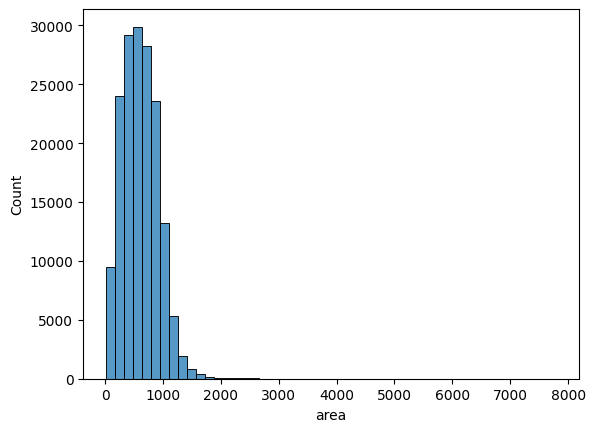

In [61]:
# Plot nuclei area
sns.histplot(adata.obs["area"], kde=False, bins=50) 

#### **Genes Visualization on tissue**

/tmp/ipykernel_650251/3488420921.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


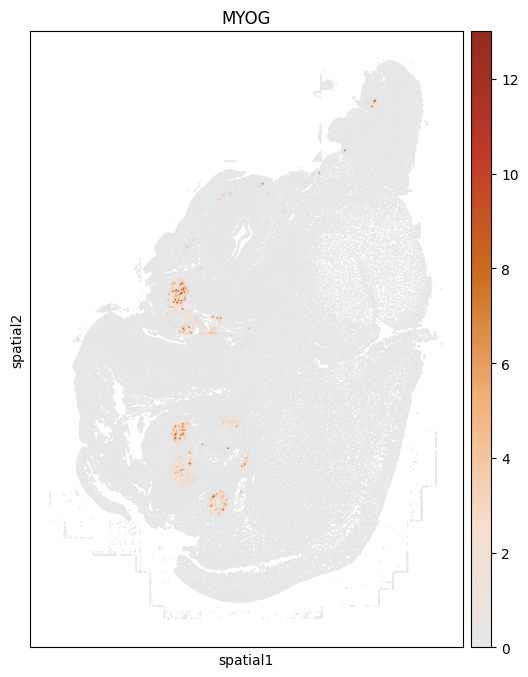

In [65]:
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(
    adata,
    color="MYOG",
    spot_size=100,
    color_map=orange_red_cmap,
    ax=ax,          # Pass your axis
    show=False      # Don't display, allows saving. OTHERWISE IT DOES NOT SAVE IT
)
plt.savefig('myog.svg', bbox_inches='tight')

/tmp/ipykernel_650251/3319461201.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


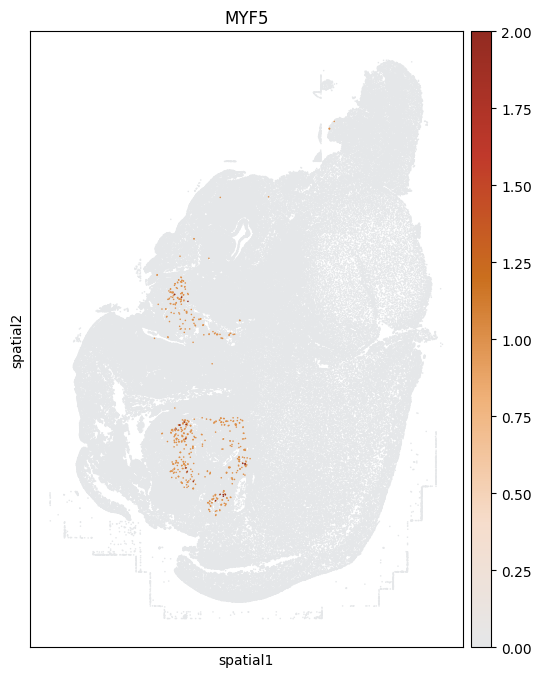

In [66]:
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(
    adata,
    color="MYF5",
    spot_size=100,
    color_map=orange_red_cmap,
    ax=ax,          # Pass your axis
    show=False      # Don't display, allows saving
)
plt.savefig('myf5.svg', bbox_inches='tight')

In [67]:
# I did not find MYOD but according to Ensembl, it's called MDFI
adata.var.loc["MDFI"]

gene_ids         ENSG00000112559
feature_types    Gene Expression
genome                    GRCh38
Name: MDFI, dtype: object

/tmp/ipykernel_650251/1126567015.py:2: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(


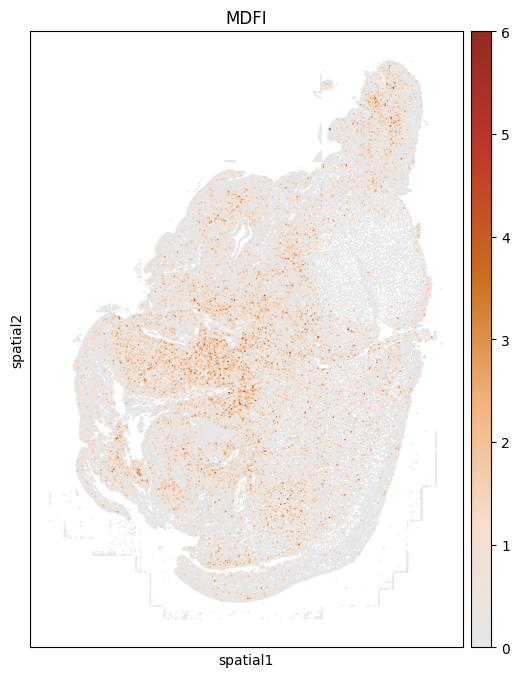

In [68]:
fig, ax = plt.subplots(figsize=(10, 8))
sc.pl.spatial(
    adata,
    color="MDFI",
    spot_size=100,
    color_map=orange_red_cmap,
    ax=ax,          # Pass your axis
    show=False      # Don't display, allows saving. OTHERWISE IT DOES NOT SAVE IT
)
plt.savefig('myod.svg', bbox_inches='tight')

In [ ]:
# Plotting without saving
sc.pl.spatial(adata, color="TTN", spot_size=80, color_map=orange_red_cmap)

In [ ]:
sc.pl.spatial(adata, color="TBX1", spot_size=80, color_map=orange_red_cmap)

In [ ]:
sc.pl.spatial(adata, color="PAX3", spot_size=80, color_map=orange_red_cmap)

In [ ]:
sc.pl.spatial(adata, color="PITX2", spot_size=80, color_map=orange_red_cmap)

## Downstream Analysis

### QC & normalization

In [50]:
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], inplace=True)
adata

AnnData object with n_obs × n_vars = 166530 × 18085
    obs: 'region', 'slide', 'cell_id', 'area', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'feature_types', 'genome', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts'
    uns: 'sopa_attrs', 'spatialdata_attrs'
    obsm: 'bins_assignments', 'spatial'

<Axes: xlabel='n_genes_by_counts', ylabel='Count'>

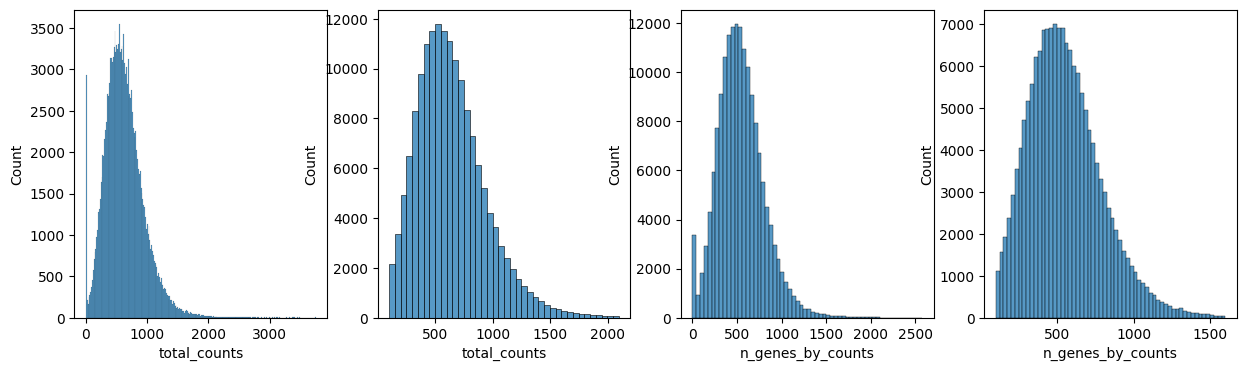

In [51]:
# Select the thresholds

fig, axs = plt.subplots(1, 4, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])

# Use this one to visualize potential thresholds
sns.histplot(
    adata.obs["total_counts"][(adata.obs["total_counts"] > 100) & (adata.obs["total_counts"] < 2100)],
    kde=False,
    bins=40,
    ax=axs[1],
)
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[2])

# Use this one to visualize potential thresholds 
sns.histplot(
    adata.obs["n_genes_by_counts"][(adata.obs["n_genes_by_counts"] > 100) & (adata.obs["n_genes_by_counts"] < 1600)],
    kde=False,
    bins=60,
    ax=axs[3],
)

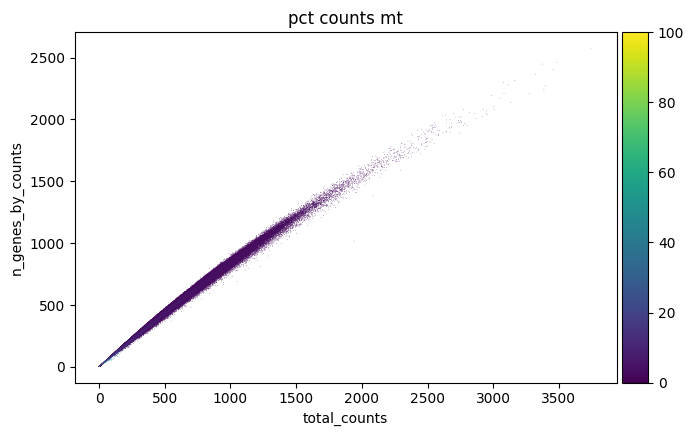

In [52]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pct_counts_mt")

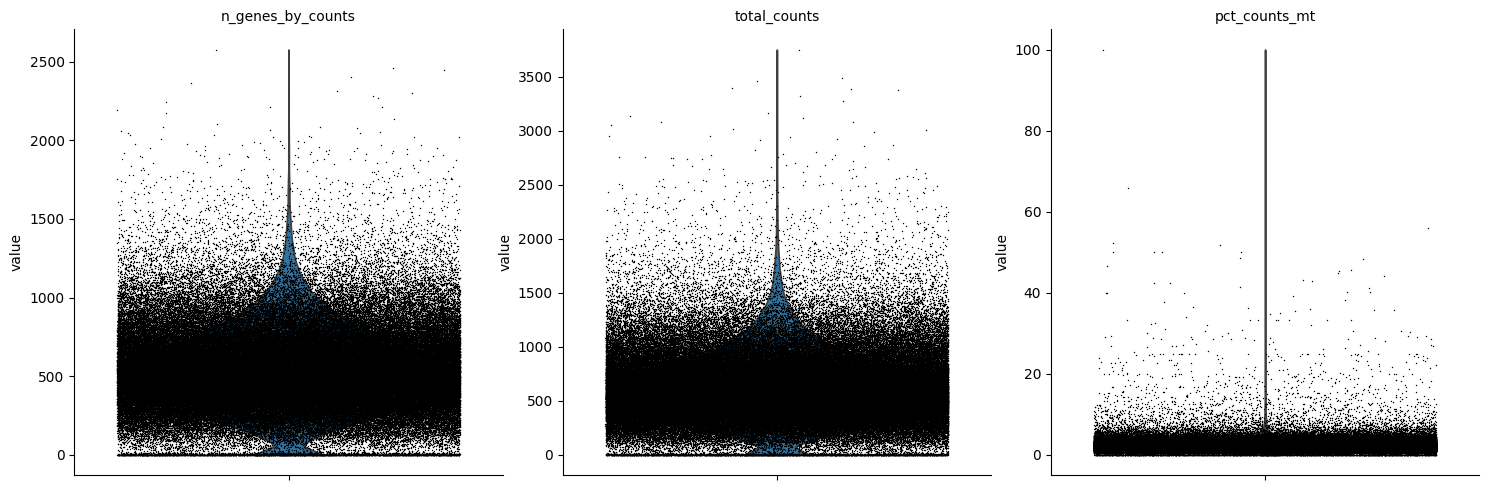

In [53]:
sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True,
)

In [54]:
# Filter #

# Filter total_counts
sc.pp.filter_cells(adata, min_counts=100)
sc.pp.filter_cells(adata, max_counts=2100)

# Filter n_genes_by_counts
sc.pp.filter_genes(adata, min_cells=100)
sc.pp.filter_genes(adata, max_cells=1600)

# Filter based on mitochondrial percentage
adata = adata[adata.obs["pct_counts_mt"] < 10].copy()
print(f"#cells after MT filter: {adata.n_obs}")


KeyboardInterrupt: 

In [ ]:
# Visualize after filtering

fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
sns.histplot(adata.obs["n_genes_by_counts"], kde=False, ax=axs[1])

In [ ]:
adata

In [ ]:
# Normalization and HVG #

sc.pp.normalize_total(adata, inplace=True)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

In [ ]:
adata.obs

In [ ]:
adata.var

### Embedding & Clustering

#### **PCA**

In [ ]:
sc.pp.pca(adata)
sc.pl.pca_variance_ratio(adata, n_pcs=50, log=True)

In [ ]:
sc.pl.pca(
    adata,
    color=["total_counts"],
    dimensions=[(0, 1), (0, 2), (1, 2), (2,3), (1,3)],
    ncols=3,
    size=2,
)

#### **UMAP**

In [ ]:
sc.pp.neighbors(adata, n_pcs=16)
sc.tl.umap(adata)

In [ ]:
sc.pl.umap(
    adata,
    color="area",
    size=2,
)

###################################################

In [ ]:
# Compute UMAP
sc.pp.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

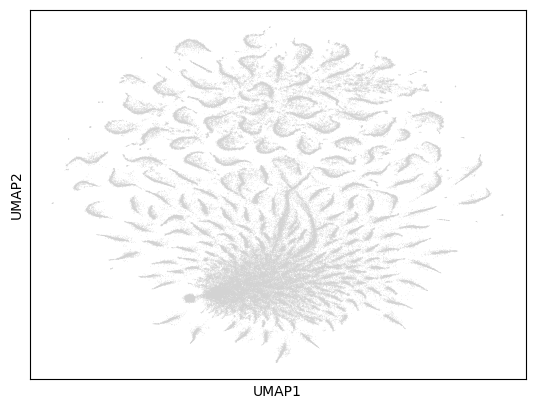

In [16]:
sc.pl.umap(adata)

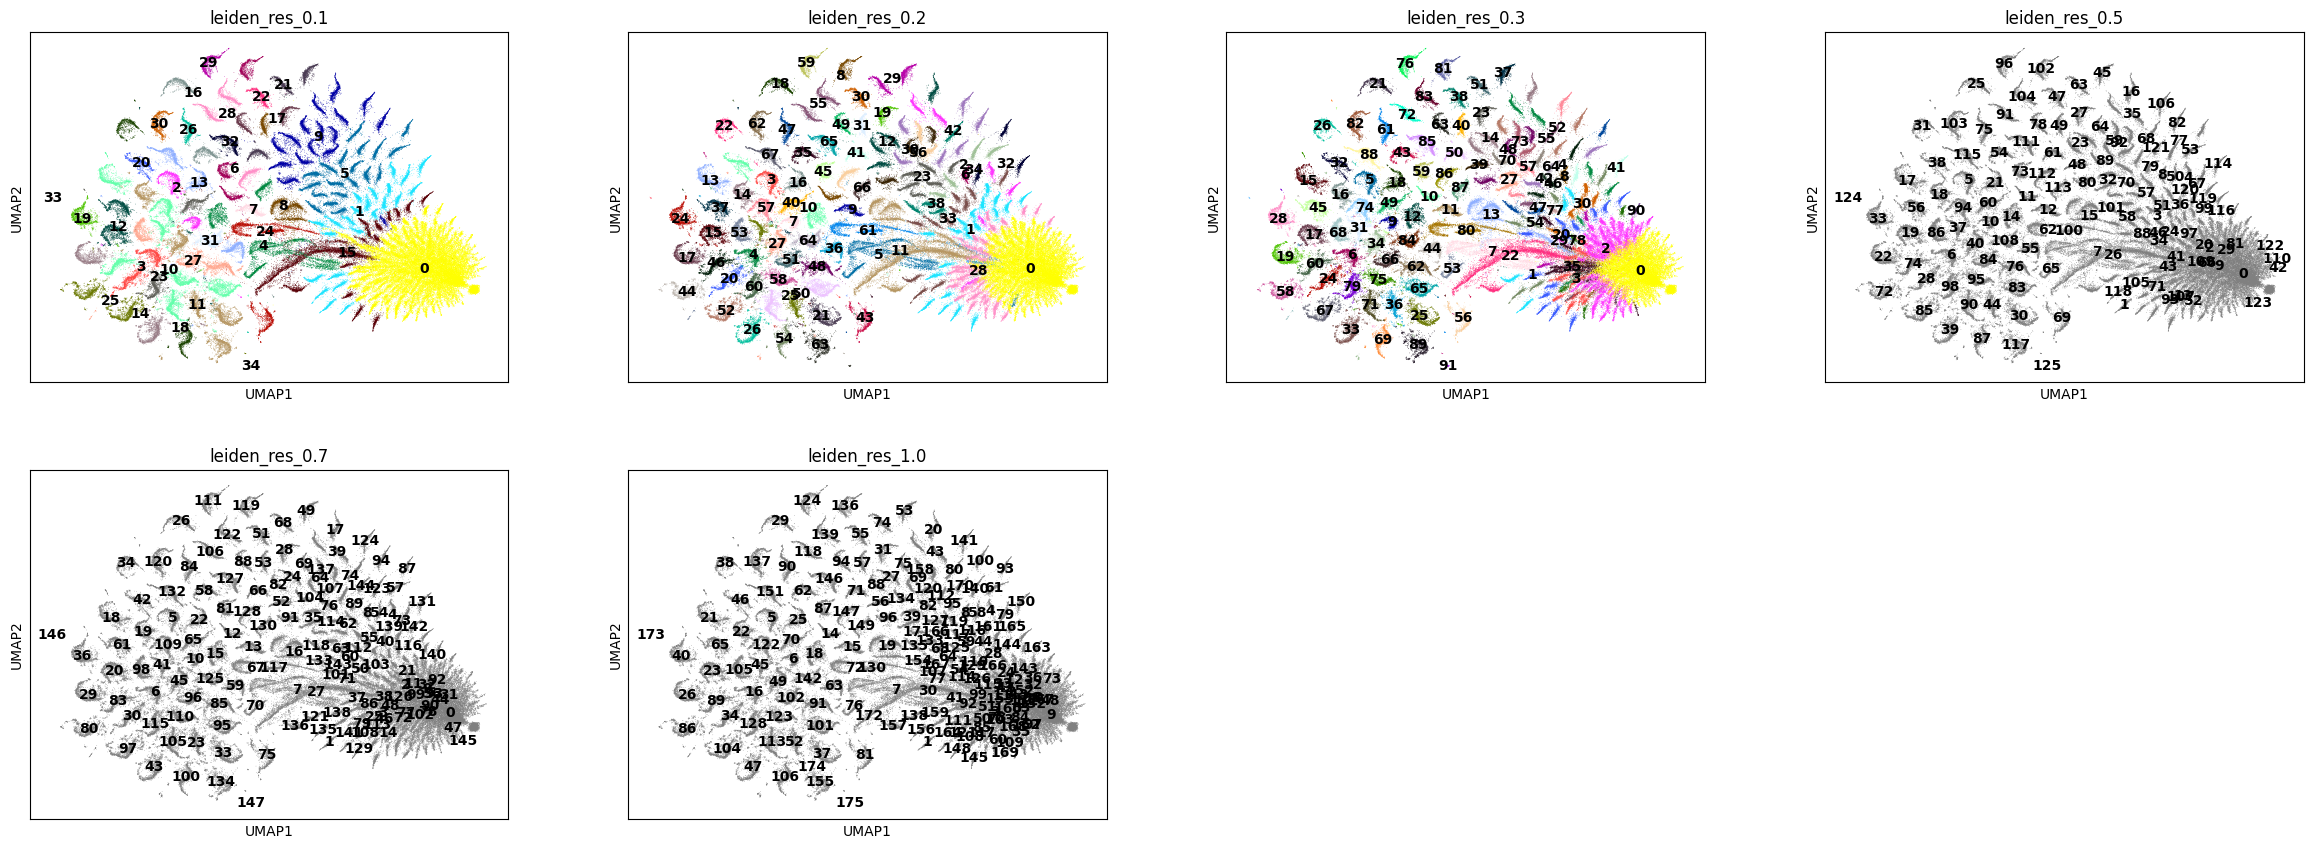

KeyError: 'Could not find key clusters in .var_names or .obs.columns.'

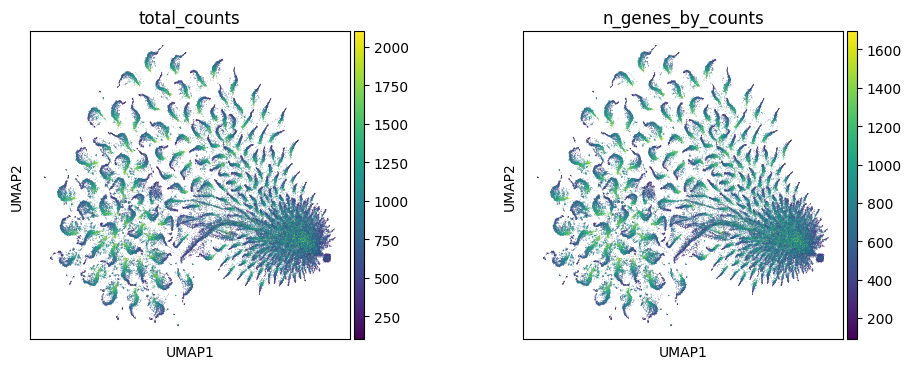

In [42]:
for res in [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    sc.tl.leiden(
        adata, key_added=f"leiden_res_{res}", resolution=res, flavor="igraph"
    )

sc.pl.umap(
    adata,
    color=["leiden_res_0.1","leiden_res_0.2","leiden_res_0.3", "leiden_res_0.5", "leiden_res_0.7", "leiden_res_1.0"],
    legend_loc="on data",
    color_map="tab20")

# Plot UMAP
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)


In [ ]:
plt.rcParams["figure.figsize"] = (8, 8)
sc.pl.spatial(adata, img_key="hires", color=["total_counts", "n_genes_by_counts"])

In [ ]:
# Clustering on whole tissue
plot_clusters_and_save_image(title="Entire tissue", gdf=gdf, img=img, adata=adata, color_by_obs="leiden_res_0.1", buffer=20) 

In [ ]:
# Marker genes to annotate clusters
sc.tl.rank_genes_groups(adata, groupby="leiden_res_0.1", method="wilcoxon")
sc.pl.rank_genes_groups_dotplot(adata, groupby="leiden_res_0.1", standard_scale="var", n_genes=5)